In [1]:
# ================================
# 1. IMPORT LIBRARIES
# ================================
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import pickle

# ================================
# 2. LOAD DATASET
# ================================
df = pd.read_csv("city_day.csv")

print("Dataset Shape:", df.shape)
print(df.head())

# ================================
# 3. DATA CLEANING
# ================================
# Remove unnecessary columns
df = df.drop(columns=["Date", "City"])

# Drop rows with missing target
df = df.dropna(subset=["AQI_Bucket"])

# Fill missing values with mean
df.fillna(df.mean(numeric_only=True), inplace=True)

# ================================
# 4. FEATURE SELECTION
# ================================
features = ["PM2.5", "PM10", "NO2", "CO", "SO2", "O3"]
X = df[features]

y = df["AQI_Bucket"]

# ================================
# 5. ENCODE TARGET
# ================================
le = LabelEncoder()
y = le.fit_transform(y)

# ================================
# 6. TRAIN TEST SPLIT
# ================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ================================
# 7. MODEL TRAINING
# ================================
model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

model.fit(X_train, y_train)

# ================================
# 8. PREDICTION
# ================================
y_pred = model.predict(X_test)

# ================================
# 9. EVALUATION
# ================================
print("\nAccuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

# ================================
# 10. FEATURE IMPORTANCE
# ================================
importance = model.feature_importances_

print("\nFeature Importance:")
for i, col in enumerate(features):
    print(f"{col}: {importance[i]:.4f}")

# ================================
# 11. SAVE MODEL
# ================================
pickle.dump(model, open("aqi_model.pkl", "wb"))
pickle.dump(le, open("label_encoder.pkl", "wb"))

print("\nModel saved successfully!")

# ================================
# 12. SAMPLE PREDICTION
# ================================
sample = np.array([[80, 120, 40, 1.2, 10, 30]])
pred = model.predict(sample)

print("\nPredicted AQI Category:", le.inverse_transform(pred))

Dataset Shape: (29531, 16)
        City        Date  PM2.5  PM10     NO    NO2    NOx  NH3     CO    SO2  \
0  Ahmedabad  2015-01-01    NaN   NaN   0.92  18.22  17.15  NaN   0.92  27.64   
1  Ahmedabad  2015-01-02    NaN   NaN   0.97  15.69  16.46  NaN   0.97  24.55   
2  Ahmedabad  2015-01-03    NaN   NaN  17.40  19.30  29.70  NaN  17.40  29.07   
3  Ahmedabad  2015-01-04    NaN   NaN   1.70  18.48  17.97  NaN   1.70  18.59   
4  Ahmedabad  2015-01-05    NaN   NaN  22.10  21.42  37.76  NaN  22.10  39.33   

       O3  Benzene  Toluene  Xylene  AQI AQI_Bucket  
0  133.36     0.00     0.02    0.00  NaN        NaN  
1   34.06     3.68     5.50    3.77  NaN        NaN  
2   30.70     6.80    16.40    2.25  NaN        NaN  
3   36.08     4.43    10.14    1.00  NaN        NaN  
4   39.31     7.01    18.89    2.78  NaN        NaN  

Accuracy: 0.7849094567404427

Classification Report:

              precision    recall  f1-score   support

           0       0.83      0.58      0.68       28

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


Dataset Shape: (29531, 16)
        City        Date  PM2.5  PM10     NO    NO2    NOx  NH3     CO    SO2  \
0  Ahmedabad  2015-01-01    NaN   NaN   0.92  18.22  17.15  NaN   0.92  27.64   
1  Ahmedabad  2015-01-02    NaN   NaN   0.97  15.69  16.46  NaN   0.97  24.55   
2  Ahmedabad  2015-01-03    NaN   NaN  17.40  19.30  29.70  NaN  17.40  29.07   
3  Ahmedabad  2015-01-04    NaN   NaN   1.70  18.48  17.97  NaN   1.70  18.59   
4  Ahmedabad  2015-01-05    NaN   NaN  22.10  21.42  37.76  NaN  22.10  39.33   

       O3  Benzene  Toluene  Xylene  AQI AQI_Bucket  
0  133.36     0.00     0.02    0.00  NaN        NaN  
1   34.06     3.68     5.50    3.77  NaN        NaN  
2   30.70     6.80    16.40    2.25  NaN        NaN  
3   36.08     4.43    10.14    1.00  NaN        NaN  
4   39.31     7.01    18.89    2.78  NaN        NaN  

Best Parameters: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 200}

Accuracy: 0.8032193158953722

Classification Report:

              precision 

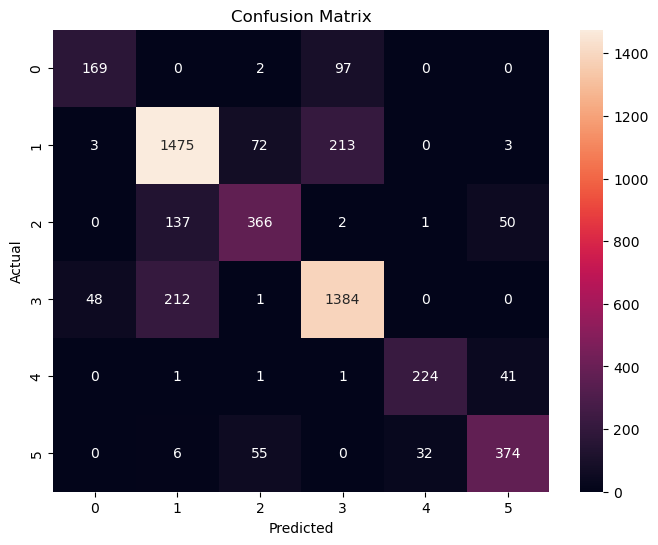


Feature Importance:
PM2.5: 0.3551
PM10: 0.2066
NO2: 0.0916
CO: 0.1718
SO2: 0.0815
O3: 0.0934

Model saved successfully!

Predicted AQI Category: Moderate


In [2]:
# ================================
# 🔹 IMPORTS
# ================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# ================================
# 🔹 LOAD DATA
# ================================
df = pd.read_csv("city_day.csv")

print("Dataset Shape:", df.shape)
print(df.head())
print("step1")
# ================================
# 🔹 DATA CLEANING
# ================================
# Select important columns
df = df[['PM2.5','PM10','NO2','CO','SO2','O3','AQI_Bucket']]

# Handle missing values (better than drop)
df.fillna(df.median(numeric_only=True), inplace=True)

# Drop remaining null target
df.dropna(subset=['AQI_Bucket'], inplace=True)

# ================================
# 🔹 ENCODING TARGET
# ================================
le = LabelEncoder()
df['AQI_Bucket'] = le.fit_transform(df['AQI_Bucket'])

# ================================
# 🔹 FEATURES & TARGET
# ================================
X = df[['PM2.5','PM10','NO2','CO','SO2','O3']]
y = df['AQI_Bucket']

# ================================
# 🔹 FEATURE SCALING
# ================================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ================================
# 🔹 TRAIN TEST SPLIT
# ================================
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

# ================================
# 🔹 MODEL (TUNED RANDOM FOREST)
# ================================
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5]
}

rf = RandomForestClassifier(random_state=42)

grid = GridSearchCV(rf, param_grid, cv=3, n_jobs=-1)
grid.fit(X_train, y_train)

model = grid.best_estimator_

print("\nBest Parameters:", grid.best_params_)

# ================================
# 🔹 PREDICTIONS
# ================================
y_pred = model.predict(X_test)

# ================================
# 🔹 PERFORMANCE METRICS
# ================================
accuracy = accuracy_score(y_test, y_pred)
print("\nAccuracy:", accuracy)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# ================================
# 🔹 CONFUSION MATRIX
# ================================
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ================================
# 🔹 FEATURE IMPORTANCE
# ================================
importances = model.feature_importances_
features = X.columns

print("\nFeature Importance:")
for f, imp in zip(features, importances):
    print(f"{f}: {round(imp,4)}")

# ================================
# 🔹 SAVE MODEL
# ================================
pickle.dump(model, open("aqi_model.pkl", "wb"))
pickle.dump(le, open("label_encoder.pkl", "wb"))
pickle.dump(scaler, open("scaler.pkl", "wb"))

print("\nModel saved successfully!")

# ================================
# 🔹 TEST INPUT (NO WARNING NOW)
# ================================
pm25, pm10, no2, co, so2, o3 = 80, 120, 40, 1.2, 10, 30

input_data = pd.DataFrame(
    [[pm25, pm10, no2, co, so2, o3]],
    columns=['PM2.5','PM10','NO2','CO','SO2','O3']
)

# Apply scaling
input_scaled = scaler.transform(input_data)

prediction = model.predict(input_scaled)
result = le.inverse_transform(prediction)

print("\nPredicted AQI Category:", result[0])

Dataset Shape: (29531, 16)
        City        Date  PM2.5  PM10     NO    NO2    NOx  NH3     CO    SO2  \
0  Ahmedabad  2015-01-01    NaN   NaN   0.92  18.22  17.15  NaN   0.92  27.64   
1  Ahmedabad  2015-01-02    NaN   NaN   0.97  15.69  16.46  NaN   0.97  24.55   
2  Ahmedabad  2015-01-03    NaN   NaN  17.40  19.30  29.70  NaN  17.40  29.07   
3  Ahmedabad  2015-01-04    NaN   NaN   1.70  18.48  17.97  NaN   1.70  18.59   
4  Ahmedabad  2015-01-05    NaN   NaN  22.10  21.42  37.76  NaN  22.10  39.33   

       O3  Benzene  Toluene  Xylene  AQI AQI_Bucket  
0  133.36     0.00     0.02    0.00  NaN        NaN  
1   34.06     3.68     5.50    3.77  NaN        NaN  
2   30.70     6.80    16.40    2.25  NaN        NaN  
3   36.08     4.43    10.14    1.00  NaN        NaN  
4   39.31     7.01    18.89    2.78  NaN        NaN  


C:\Users\junction pc\AppData\Local\Temp\ipykernel_16184\296181064.py:31: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='ffill').fillna(method='bfill')



🔥 Accuracy: 0.8169967834772304

📊 Classification Report:

              precision    recall  f1-score   support

           0       0.85      0.76      0.80       364
           1       0.81      0.83      0.82      1936
           2       0.69      0.69      0.69       627
           3       0.86      0.86      0.86      2094
           4       0.81      0.79      0.80       282
           5       0.80      0.78      0.79       604

    accuracy                           0.82      5907
   macro avg       0.80      0.79      0.79      5907
weighted avg       0.82      0.82      0.82      5907



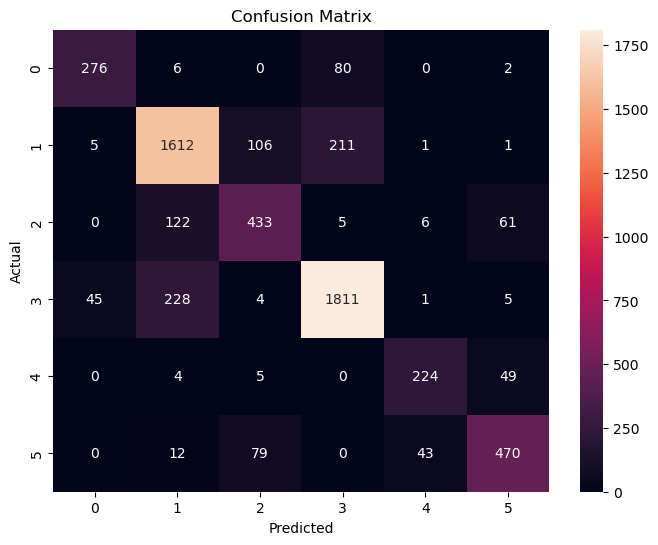


📌 Feature Importance:
PM2.5: 0.3381
PM10: 0.1453
NO2: 0.0631
CO: 0.1618
SO2: 0.0576
O3: 0.0654
NO: 0.0641
NOx: 0.0554
NH3: 0.0493

✅ Model saved successfully!

🔮 Predicted AQI Category: Moderate


In [1]:
# ================================
# 🔹 IMPORTS
# ================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import joblib

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# ================================
# 🔹 LOAD DATA
# ================================
df = pd.read_csv("city_day.csv")

print("Dataset Shape:", df.shape)
print(df.head())

# ================================
# 🔹 DATA CLEANING (IMPROVED)
# ================================
# 🔥 Added 3 more important features
df = df[['PM2.5','PM10','NO2','CO','SO2','O3','NO','NOx','NH3','AQI_Bucket']]

# 🔥 Better missing value handling (time-series)
df = df.fillna(method='ffill').fillna(method='bfill')

# Drop any remaining null target
df.dropna(subset=['AQI_Bucket'], inplace=True)

# ================================
# 🔹 ENCODING TARGET
# ================================
le = LabelEncoder()
df['AQI_Bucket'] = le.fit_transform(df['AQI_Bucket'])

# ================================
# 🔹 FEATURES & TARGET
# ================================
X = df[['PM2.5','PM10','NO2','CO','SO2','O3','NO','NOx','NH3']]
y = df['AQI_Bucket']

# ================================
# 🔹 FEATURE SCALING
# ================================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ================================
# 🔹 TRAIN TEST SPLIT
# ================================
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

# ================================
# 🔹 MODEL (IMPROVED)
# ================================
model = RandomForestClassifier(
    n_estimators=150,          # 🔥 better accuracy
    max_depth=None,            # 🔥 no limit = better learning
    min_samples_split=5,
    class_weight='balanced',   # 🔥 improves class 0
    random_state=42,
    n_jobs=-1
)

# 🔥 TRAIN MODEL
model.fit(X_train, y_train)

# ================================
# 🔹 PREDICTIONS
# ================================
y_pred = model.predict(X_test)

# ================================
# 🔹 PERFORMANCE METRICS
# ================================
accuracy = accuracy_score(y_test, y_pred)
print("\n🔥 Accuracy:", accuracy)

print("\n📊 Classification Report:\n")
print(classification_report(y_test, y_pred))

# ================================
# 🔹 CONFUSION MATRIX
# ================================
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ================================
# 🔹 FEATURE IMPORTANCE
# ================================
importances = model.feature_importances_
features = X.columns

print("\n📌 Feature Importance:")
for f, imp in zip(features, importances):
    print(f"{f}: {round(imp,4)}")

# ================================
# 🔹 SAVE MODEL (SMALL SIZE)
# ================================
joblib.dump(model, "aqi_model.pkl", compress=5)   # 🔥 compressed
pickle.dump(le, open("label_encoder.pkl", "wb"))
pickle.dump(scaler, open("scaler.pkl", "wb"))

print("\n✅ Model saved successfully!")

# ================================
# 🔹 TEST INPUT
# ================================
pm25, pm10, no2, co, so2, o3, no, nox, nh3 = 80, 120, 40, 1.2, 10, 30, 20, 35, 15

input_data = pd.DataFrame(
    [[pm25, pm10, no2, co, so2, o3, no, nox, nh3]],
    columns=['PM2.5','PM10','NO2','CO','SO2','O3','NO','NOx','NH3']
)

# Scale input
input_scaled = scaler.transform(input_data)

prediction = model.predict(input_scaled)
result = le.inverse_transform(prediction)

print("\n🔮 Predicted AQI Category:", result[0])